In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo
df = pd.read_csv('owid-covid-data.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (429435, 67)

Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_va

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [2]:
# India ka data filter karo
countries = ['India', 'United States', 'Brazil', 'United Kingdom']
df_filtered = df[df['location'].isin(countries)].copy()
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

print(df_filtered['location'].value_counts())

location
India             1682
Brazil            1674
United Kingdom    1674
United States     1674
Name: count, dtype: int64


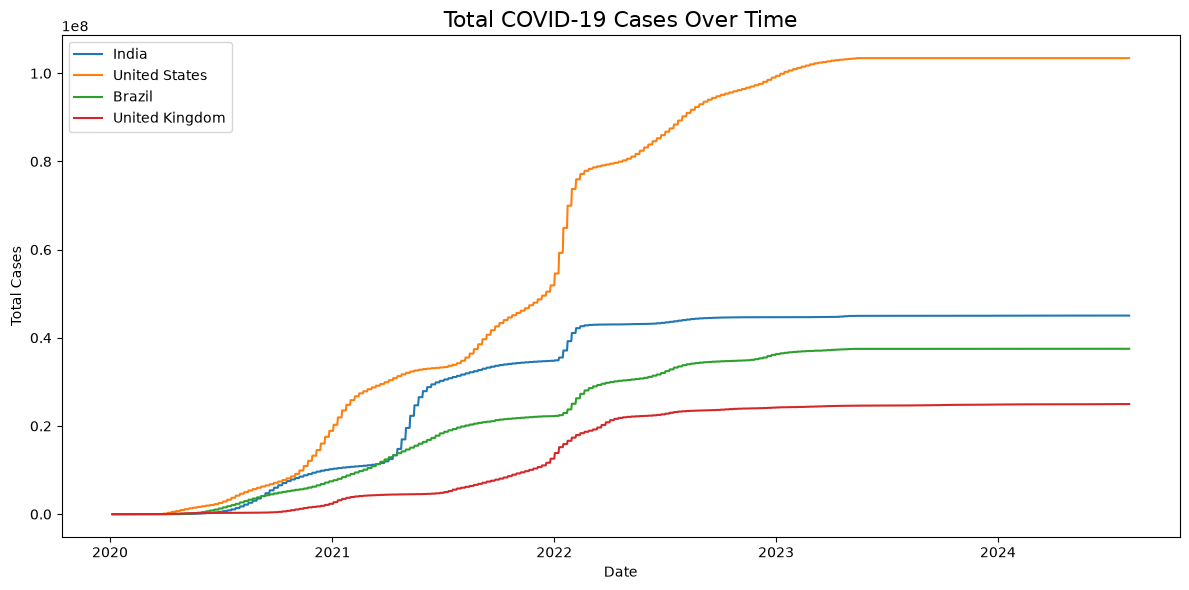

In [3]:
# Total Cases Over Time - Line Chart
plt.figure(figsize=(12, 6))

for country in countries:
    data = df_filtered[df_filtered['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.title("Total COVID-19 Cases Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21376\4179269786.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest, x='location', y='death_rate', palette='Reds_d')


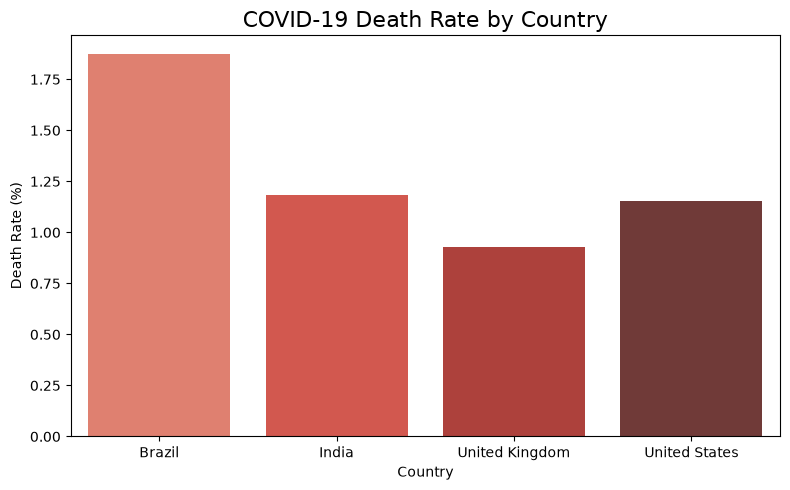

In [4]:
# Death Rate by Country
df_filtered['death_rate'] = (
    df_filtered['total_deaths'] / df_filtered['total_cases']
) * 100

latest = df_filtered.groupby('location').last().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=latest, x='location', y='death_rate', palette='Reds_d')
plt.title("COVID-19 Death Rate by Country", fontsize=16)
plt.ylabel("Death Rate (%)")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

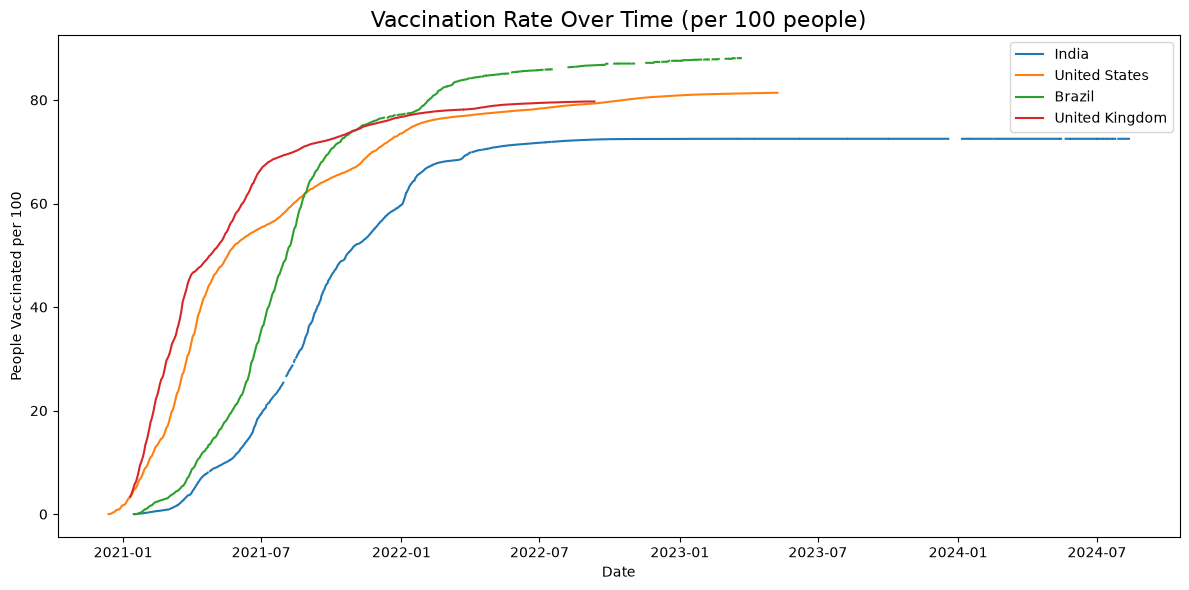

In [5]:
# Vaccination Progress Over Time
plt.figure(figsize=(12, 6))

for country in countries:
    data = df_filtered[df_filtered['location'] == country]
    plt.plot(data['date'], data['people_vaccinated_per_hundred'], label=country)

plt.title("Vaccination Rate Over Time (per 100 people)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("People Vaccinated per 100")
plt.legend()
plt.tight_layout()
plt.show()

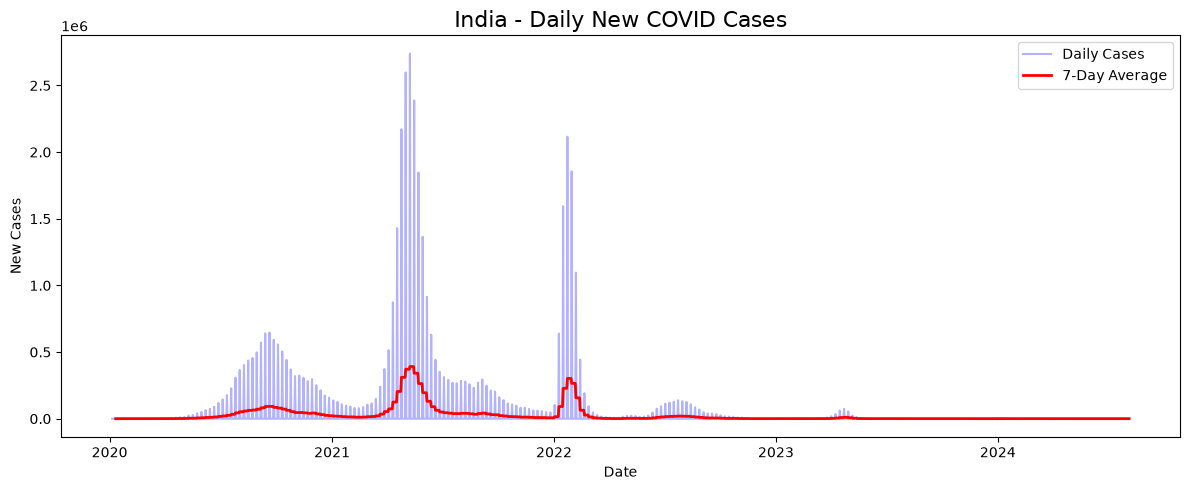

In [6]:
# India - Daily New Cases with 7-Day Rolling Average
india = df_filtered[df_filtered['location'] == 'India'].copy()
india['rolling_avg'] = india['new_cases'].rolling(7).mean()

plt.figure(figsize=(12, 5))
plt.plot(india['date'], india['new_cases'], alpha=0.3, color='blue', label='Daily Cases')
plt.plot(india['date'], india['rolling_avg'], color='red', linewidth=2, label='7-Day Average')
plt.title("India - Daily New COVID Cases", fontsize=16)
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.legend()
plt.tight_layout()
plt.show()

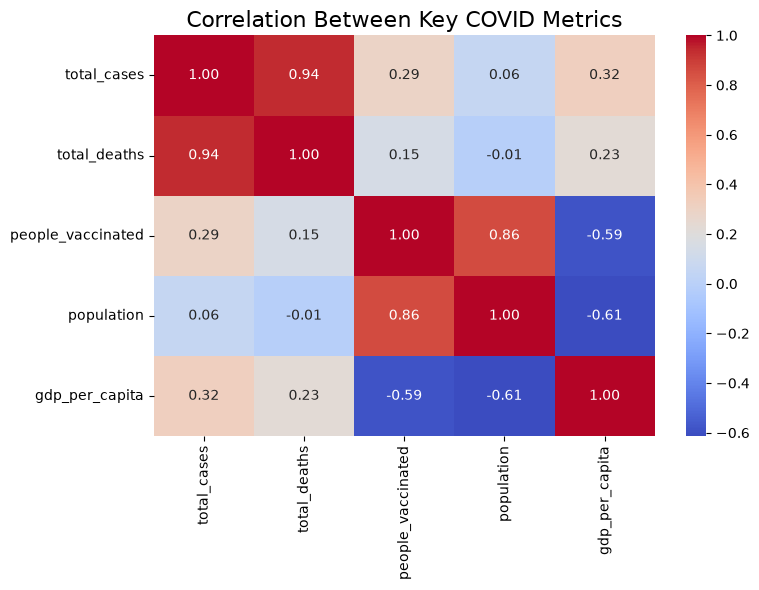

In [7]:
# Correlation Heatmap
cols = ['total_cases', 'total_deaths', 
        'people_vaccinated', 'population', 
        'gdp_per_capita']

corr = df_filtered[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Key COVID Metrics", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Chart 1 — Total Cases Over Time ──
fig1 = px.line(
    df_filtered, 
    x='date', 
    y='total_cases',
    color='location',
    title='Total COVID-19 Cases Over Time',
    labels={'total_cases': 'Total Cases', 'date': 'Date', 'location': 'Country'}
)
fig1.show()

In [9]:
# ── Chart 2 — Top 10 Countries by Total Cases ──
latest_data = df.groupby('location').last().reset_index()
latest_data = latest_data[latest_data['continent'].notna()]
top10 = latest_data.nlargest(10, 'total_cases')

fig2 = px.bar(
    top10,
    x='total_cases',
    y='location',
    orientation='h',
    title='Top 10 Countries by Total COVID-19 Cases',
    labels={'total_cases': 'Total Cases', 'location': 'Country'},
    color='total_cases',
    color_continuous_scale='Reds'
)
fig2.show()

In [10]:
# ── Chart 3 — World Map ──
fig3 = px.choropleth(
    latest_data,
    locations='iso_code',
    color='total_cases',
    hover_name='location',
    color_continuous_scale='Reds',
    title='COVID-19 Total Cases World Map',
    labels={'total_cases': 'Total Cases'}
)
fig3.show()

In [11]:
# ── Save Complete Dashboard as HTML ──
from plotly.subplots import make_subplots
import plotly.io as pio

# Combine all charts
dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Total Cases Over Time',
        'Top 10 Countries',
        'World Map',
        'Vaccination Progress'
    )
)

# Save each chart separately
fig1.write_html('cases_over_time.html')
fig2.write_html('top10_countries.html')
fig3.write_html('world_map.html')

print("All charts saved!")
print("Check your C:\\covid_analysis folder!")

All charts saved!
Check your C:\covid_analysis folder!


In [12]:
# ── Save ALL charts in ONE HTML file ──
with open('covid_dashboard.html', 'w') as f:
    f.write('''
    <html>
    <head>
        <title>COVID-19 Dashboard</title>
        <style>
            body { font-family: Arial; background: #f0f2f5; margin: 0; padding: 20px; }
            h1 { text-align: center; color: #1f2937; padding: 20px; }
            .chart-box { background: white; border-radius: 12px; 
                         padding: 20px; margin-bottom: 30px; 
                         box-shadow: 0 2px 10px rgba(0,0,0,0.1); }
        </style>
    </head>
    <body>
        <h1>🦠 COVID-19 Global Analysis Dashboard</h1>
        <div class="chart-box">''' + fig1.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig2.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig3.to_html(full_html=False) + '''</div>
    </body>
    </html>
    ''')

print("Dashboard saved! Open covid_dashboard.html")

UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f9a0' in position 499: character maps to <undefined>

In [13]:
# ── Save ALL charts in ONE HTML file ──
with open('covid_dashboard.html', 'w', encoding='utf-8') as f:
    f.write('''
    <html>
    <head>
        <title>COVID-19 Dashboard</title>
        <style>
            body { font-family: Arial; background: #f0f2f5; margin: 0; padding: 20px; }
            h1 { text-align: center; color: #1f2937; padding: 20px; }
            .chart-box { background: white; border-radius: 12px; 
                         padding: 20px; margin-bottom: 30px; 
                         box-shadow: 0 2px 10px rgba(0,0,0,0.1); }
        </style>
    </head>
    <body>
        <h1>🦠 COVID-19 Global Analysis Dashboard</h1>
        <div class="chart-box">''' + fig1.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig2.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig3.to_html(full_html=False) + '''</div>
    </body>
    </html>
    ''')

print("Dashboard saved! Open covid_dashboard.html")

Dashboard saved! Open covid_dashboard.html


In [14]:
# Vaccination vs Death Rate Comparison
fig4 = px.scatter(
    latest_data,
    x='people_vaccinated_per_hundred',
    y='total_deaths_per_million',
    hover_name='location',
    color='continent',
    size='population',
    title='Vaccination Rate vs Death Rate by Country',
    labels={
        'people_vaccinated_per_hundred': 'People Vaccinated per 100',
        'total_deaths_per_million': 'Total Deaths per Million',
        'continent': 'Continent'
    }
)
fig4.show()

In [ ]:
# ── Save ALL 4 charts in ONE Dashboard HTML file ──
with open('covid_dashboard.html', 'w', encoding='utf-8') as f:
    f.write('''
    <html>
    <head>
        <title>COVID-19 Dashboard</title>
        <style>
            body { font-family: Arial; background: #f0f2f5; margin: 0; padding: 20px; }
            h1 { text-align: center; color: #1f2937; padding: 20px; font-size: 32px; }
            p { text-align: center; color: #6b7280; margin-bottom: 30px; }
            .chart-box { 
                background: white; 
                border-radius: 12px; 
                padding: 20px; 
                margin-bottom: 30px; 
                box-shadow: 0 2px 10px rgba(0,0,0,0.1); 
            }
        </style>
    </head>
    <body>
        <h1>🦠 COVID-19 Global Analysis Dashboard</h1>
        <p>Analyzed by Suhana Mansuri | Data Source: Our World in Data</p>
        
        <div class="chart-box">''' + fig1.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig2.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig3.to_html(full_html=False) + '''</div>
        <div class="chart-box">''' + fig4.to_html(full_html=False) + '''</div>
    </body>
    </html>
    ''')

print("Dashboard updated with 4 charts!")